# BBB Dataset — Exploratory Data Analysis

Interactive EDA for the curated BBB peptide dataset and the public Hugging Face release
[`manumartinm/bbb-peptides`](https://huggingface.co/datasets/manumartinm/bbb-peptides).

**Sections**
1. Local pipeline tables (`bbb-dataset-build`)
2. Tabular + fold diagnostics (heatmaps, violins, Mann–Whitney)
3. HF structural quality (Boltz pLDDT / pTM / confidence)
4. 3D peptide structure gallery (CA traces coloured by per-residue pLDDT)
5. GSK3β therapeutic target — design spec, guidance, hotspot map (`notebooks/gsk3b.cif`)
6. UMAP embedding of physicochemical features

Run from `packages/dataset` after building the gold table:
```bash
uv sync --package bbb-dataset --extra notebook
uv run bbb-dataset-build --skip-augment --skip-fold
jupyter lab notebooks/eda.ipynb   # use the uv/.venv kernel
```

Figures are written under `data/processed/eda_figures/`.

In [18]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import yaml
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 150})

NOTEBOOK_DIR = Path.cwd().resolve()
if NOTEBOOK_DIR.name != "notebooks":
  for parent in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]:
    if (parent / "data" / "processed").exists() and parent.name == "dataset":
      NOTEBOOK_DIR = parent / "notebooks"
      break

BASE_DIR = NOTEBOOK_DIR.parent
REPO_ROOT = BASE_DIR.parent.parent

# Make `bbb_dataset` importable when the kernel cwd is notebooks/ (not only via uv run).
_SRC = BASE_DIR / "src"
if _SRC.exists() and str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))

from bbb_dataset.struct_io import load_coords_npz

PROCESSED = BASE_DIR / "data" / "processed"
EDA_DIR = PROCESSED / "eda_figures"
HF_LOCAL = REPO_ROOT / "packages" / "bbb_models" / "data" / "bbb-peptides"
GSK3B_DIR = REPO_ROOT / "packages" / "boltzgen_design" / "targets" / "gsk3b"
GSK3B_CIF = NOTEBOOK_DIR / "gsk3b.cif"
if not GSK3B_CIF.exists():
    GSK3B_CIF = GSK3B_DIR / "gsk3b.cif"
GSK3B_DESIGN_YAML = GSK3B_DIR / "gsk3b_peptide_design.yaml"
GSK3B_GUIDANCE_JSON = GSK3B_DIR / "guidance.json"
GSK3B_GUIDANCE_FEATS = GSK3B_DIR / "guidance_feats.json"

HF_REPO_ID = "manumartinm/bbb-peptides"
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

print(f"Dataset root : {BASE_DIR}")
print(f"HF local     : {HF_LOCAL} (exists={HF_LOCAL.exists()})")
print(f"GSK3β CIF    : {GSK3B_CIF} (exists={GSK3B_CIF.exists()})")
print(f"Design YAML  : {GSK3B_DESIGN_YAML} (exists={GSK3B_DESIGN_YAML.exists()})")
print(f"Guidance     : {GSK3B_GUIDANCE_JSON} (exists={GSK3B_GUIDANCE_JSON.exists()})")

Dataset root : /Users/manumartinm/Documents/ProteinDesign/alzheimer-peptide-design/packages/dataset
HF local     : /Users/manumartinm/Documents/ProteinDesign/alzheimer-peptide-design/packages/bbb_models/data/bbb-peptides (exists=True)
GSK3β CIF    : /Users/manumartinm/Documents/ProteinDesign/alzheimer-peptide-design/packages/dataset/notebooks/gsk3b.cif (exists=True)
Design YAML  : /Users/manumartinm/Documents/ProteinDesign/alzheimer-peptide-design/packages/boltzgen_design/targets/gsk3b/gsk3b_peptide_design.yaml (exists=True)
Guidance     : /Users/manumartinm/Documents/ProteinDesign/alzheimer-peptide-design/packages/boltzgen_design/targets/gsk3b/guidance.json (exists=True)


In [19]:
FEATURE_COLS = [
    "mw", "hydrophobic_ratio_pct", "pi", "net_charge_ph7", "total_charge",
    "mean_hydrophobicity", "aliphatic_index", "boman_index", "aromaticity",
    "instability_index", "gravy",
]
AA_PCT_COLS = [
    "aa_basic_pct", "aa_acidic_pct", "aa_aromatic_pct",
    "aa_hydrophobic_pct", "aa_polar_pct",
]
STRUCT_COLS = [
    "plddt", "ptm", "structure_confidence", "iptm",
    "complex_iplddt", "complex_pde", "complex_ipde",
]
COMPARISON_FEATURES = ["length", "gravy", "net_charge_ph7", "boman_index", "instability_index"]


def save_fig(fig: plt.Figure, path: Path) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, bbox_inches="tight")
    plt.close(fig)
    return path


def dataset_overview_table(df: pd.DataFrame, *, name: str = "dataset") -> pd.DataFrame:
    pos = int((df["bbb_label"] == 1).sum())
    neg = int((df["bbb_label"] == 0).sum())
    return pd.DataFrame([{
        "dataset": name,
        "rows": len(df),
        "bbb_positive": pos,
        "bbb_negative": neg,
        "positive_ratio": round(pos / len(df), 4) if len(df) else 0.0,
        "length_median": float(df["length"].median()) if len(df) else float("nan"),
        "unique_sequences": int(df["sequence"].nunique()),
        "unique_clusters": int(df["cluster_id"].nunique()) if "cluster_id" in df.columns else float("nan"),
    }])


def fold_overview_table(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for fold_id, group in df.groupby("fold_id", sort=True):
        rows.append({
            "fold_id": int(fold_id),
            "rows": len(group),
            "bbb_positive": int((group["bbb_label"] == 1).sum()),
            "positive_ratio": round(float(group["bbb_label"].mean()), 4),
            "unique_clusters": int(group["cluster_id"].nunique()),
            "external_test_rows": int(group.get("external_test", pd.Series([0] * len(group))).sum()),
        })
    return pd.DataFrame(rows).sort_values("fold_id").reset_index(drop=True)


def cluster_leakage_table(df: pd.DataFrame) -> pd.DataFrame:
    cv = df[(df.get("external_test", 0) == 0) & (df["fold_id"] >= 0)].copy()
    if cv.empty:
        return pd.DataFrame(columns=["cluster_id", "n_folds", "fold_ids"])
    grouped = cv.groupby("cluster_id")["fold_id"].agg(
        n_folds="nunique", fold_ids=lambda s: sorted(set(int(x) for x in s))
    ).reset_index()
    return grouped[grouped["n_folds"] > 1].sort_values("n_folds", ascending=False).reset_index(drop=True)


def mannwhitney_by_label(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    pos = df[df["bbb_label"] == 1]
    neg = df[df["bbb_label"] == 0]
    rows = []
    for col in cols:
        if col not in df.columns:
            continue
        stat, p = stats.mannwhitneyu(pos[col], neg[col], alternative="two-sided")
        rows.append({
            "feature": col,
            "median_bbb_pos": float(pos[col].median()),
            "median_bbb_neg": float(neg[col].median()),
            "u_stat": float(stat),
            "p_value": float(p),
        })
    out = pd.DataFrame(rows).sort_values("p_value")
    out["significant_0.05"] = out["p_value"] < 0.05
    return out


def label_mean_heatmap(df: pd.DataFrame, cols: list[str], title: str, path: Path) -> None:
    usable = [c for c in cols if c in df.columns]
    pivot = df.groupby("bbb_label")[usable].median()
    pivot.index = pivot.index.map({0: "BBB−", 1: "BBB+"})
    fig, ax = plt.subplots(figsize=(max(8, len(usable) * 0.45), 3.5))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlBu_r", center=0, ax=ax)
    ax.set_title(title)
    save_fig(fig, path)

## 1. Load local pipeline + Hugging Face dataset

Install notebook extras: `uv sync --package bbb-dataset --extra notebook`

In [20]:
gold_df = pd.read_parquet(PROCESSED / "peptides_bbb.parquet")
combined_path = PROCESSED / "peptides_bbb_with_augmentation.parquet"
combined_df = pd.read_parquet(combined_path) if combined_path.exists() else gold_df.copy()
aug_df = (
    combined_df[combined_df.get("is_augmented", 0) == 1].copy()
    if "is_augmented" in combined_df.columns
    else combined_df.iloc[0:0]
)

hf_parquet = HF_LOCAL / "peptides.parquet"
if hf_parquet.exists():
    hf_df = pd.read_parquet(hf_parquet)
    hf_struct_root = HF_LOCAL
    print(f"HF loaded from local cache: {len(hf_df)} rows")
else:
    from datasets import load_dataset

    hf_ds = load_dataset(HF_REPO_ID, split="train")
    hf_df = hf_ds.to_pandas()
    hf_struct_root = None
    print(f"HF loaded from Hub: {len(hf_df)} rows")

if "has_structure" not in hf_df.columns:
    hf_df["has_structure"] = hf_df.get("structure_coords_path", pd.Series(dtype=object)).notna()

struct_df = hf_df[hf_df["has_structure"]].copy()
print(f"Gold: {len(gold_df)} | Combined: {len(combined_df)} | Augmented: {len(aug_df)}")
print(f"HF with structure: {len(struct_df)} / {len(hf_df)}")

HF loaded from local cache: 825 rows
Gold: 452 | Combined: 825 | Augmented: 373
HF with structure: 825 / 825


## 2. Gold dataset — overview, folds, heatmaps

In [21]:
gold_out = EDA_DIR / "gold"
gold_out.mkdir(parents=True, exist_ok=True)

overview = dataset_overview_table(gold_df, name="gold")
folds = fold_overview_table(gold_df)
leakage = cluster_leakage_table(gold_df)
mw = mannwhitney_by_label(gold_df, FEATURE_COLS + AA_PCT_COLS)

overview.to_csv(gold_out / "overview.csv", index=False)
folds.to_csv(gold_out / "fold_overview.csv", index=False)
leakage.to_csv(gold_out / "cluster_leakage.csv", index=False)
mw.to_csv(PROCESSED / "eda_mannwhitney.csv", index=False)

display(overview)
display(folds)
display(leakage if not leakage.empty else "Cluster leakage across folds: none detected.")
display(mw.head(12))

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=gold_df, x="bbb_label", hue="split", ax=ax)
ax.set_title("BBB class balance by split")
save_fig(fig, gold_out / "class_balance.png")

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=gold_df, x="length", hue="bbb_label", kde=True, bins=25, element="step", ax=ax)
ax.set_title("Length distribution")
save_fig(fig, gold_out / "length_distribution.png")

corr = gold_df[FEATURE_COLS].corr(method="spearman")
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap="vlag", center=0, ax=ax, annot=True, fmt=".2f", annot_kws={"size": 7})
ax.set_title("Spearman correlation — physicochemical features")
save_fig(fig, gold_out / "correlation_heatmap.png")

label_mean_heatmap(gold_df, FEATURE_COLS, "Median features by BBB label", gold_out / "feature_median_heatmap.png")
label_mean_heatmap(gold_df, AA_PCT_COLS, "Median AA composition (%) by BBB label", gold_out / "aa_composition_heatmap.png")

cv = gold_df[(gold_df.get("external_test", 0) == 0) & (gold_df["fold_id"] >= 0)].copy()
fold_pivot = cv.pivot_table(index="fold_id", columns="bbb_label", aggfunc="size", fill_value=0)
fold_pivot.columns = ["BBB−", "BBB+"]
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(fold_pivot, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("CV fold class counts")
save_fig(fig, gold_out / "fold_class_heatmap.png")

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, col in zip(axes.ravel(), COMPARISON_FEATURES, strict=False):
    sns.violinplot(data=gold_df, x="bbb_label", y=col, ax=ax, inner="quartile", palette="Set2")
    ax.set_xlabel("BBB label")
    ax.set_title(col)
fig.suptitle("Feature distributions by BBB label", y=1.02)
fig.tight_layout()
save_fig(fig, gold_out / "feature_violins.png")

fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=gold_df, x="source_db", hue="bbb_label", ax=ax)
ax.tick_params(axis="x", rotation=20)
ax.set_title("Source database composition")
save_fig(fig, gold_out / "source_composition.png")

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=gold_df, x="split", hue="external_test", ax=ax)
ax.set_title("Source split vs external holdout")
save_fig(fig, gold_out / "holdout_overview.png")

,dataset,rows,bbb_positive,bbb_negative,positive_ratio,length_median,unique_sequences,unique_clusters
0,gold,452,223,229,0.4934,14.0,452,452


,fold_id,rows,bbb_positive,positive_ratio,unique_clusters,external_test_rows
0,-1,92,47,0.5109,92,92
1,0,72,35,0.4861,72,0
2,1,72,35,0.4861,72,0
3,2,72,35,0.4861,72,0
4,3,72,36,0.5000,72,0
5,4,72,35,0.4861,72,0


'Cluster leakage across folds: none detected.'

,feature,median_bbb_pos,median_bbb_neg,u_stat,p_value,significant_0.05
11,aa_basic_pct,16.666667,36.842105,13253.5,8.542011e-19,True
2,pi,9.650391,11.751953,13889.0,4.985567e-17,True
4,total_charge,2.095000,5.995000,13899.0,5.286965e-17,True
3,net_charge_ph7,2.095000,5.995000,13995.0,9.491568e-17,True
8,aromaticity,0.142857,0.052632,34731.5,2.026668e-11,True
5,mean_hydrophobicity,-0.053684,-0.387407,34334.0,2.327215e-10,True
15,aa_polar_pct,25.000000,16.666667,34266.5,3.000684e-10,True
13,aa_aromatic_pct,16.666667,8.000000,33283.5,2.030668e-08,True
7,boman_index,1.957059,3.421875,18262.0,1.633877e-07,True
0,mw,1454.690000,1915.290000,19050.0,3.022921e-06,True


PosixPath('/Users/manumartinm/Documents/ProteinDesign/alzheimer-peptide-design/packages/dataset/data/processed/eda_figures/gold/holdout_overview.png')

## 3. Augmentation comparison

In [22]:
if aug_df.empty:
    print("No augmented dataset — run `bbb-dataset-augment` for pre/post plots.")
else:
    aug_out = EDA_DIR / "augmentation"
    aug_out.mkdir(parents=True, exist_ok=True)

    overview_pp = pd.concat([
        dataset_overview_table(gold_df, name="gold"),
        dataset_overview_table(aug_df, name="augmented_extra"),
        dataset_overview_table(combined_df, name="gold_plus_augmented"),
    ], ignore_index=True)
    overview_pp.to_csv(aug_out / "overview_pre_post.csv", index=False)
    display(overview_pp)

    train_gold = gold_df[(gold_df.get("external_test", 0) == 0) & (gold_df["fold_id"] != 0)]
    train_combined = combined_df[(combined_df.get("external_test", 0) == 0) & (combined_df["fold_id"] != 0)]

    fig, ax = plt.subplots(figsize=(6, 4))
    overview_pp.set_index("dataset")["rows"].plot(kind="bar", ax=ax, color=["#4c72b0", "#55a868", "#c44e52"])
    ax.set_title("Dataset size before / after augmentation")
    save_fig(fig, aug_out / "row_counts_pre_post.png")

    fig, ax = plt.subplots(figsize=(7, 4))
    sns.kdeplot(data=gold_df, x="length", label="gold", fill=True, alpha=0.35, ax=ax)
    sns.kdeplot(data=aug_df, x="length", label="augmented", fill=True, alpha=0.35, ax=ax)
    ax.legend()
    ax.set_title("Length: gold vs augmented")
    save_fig(fig, aug_out / "length_pre_post.png")

    fig, axes = plt.subplots(2, 3, figsize=(12, 7))
    for ax, col in zip(axes.ravel(), COMPARISON_FEATURES, strict=False):
        sns.kdeplot(data=train_gold, x=col, label="gold train", fill=True, alpha=0.3, ax=ax)
        sns.kdeplot(data=aug_df, x=col, label="augmented", fill=True, alpha=0.3, ax=ax)
        ax.set_title(col)
        ax.legend(fontsize=8)
    fig.suptitle("Feature shift: gold train vs augmented", y=1.02)
    fig.tight_layout()
    save_fig(fig, aug_out / "feature_shift_pre_post.png")

,dataset,rows,bbb_positive,bbb_negative,positive_ratio,length_median,unique_sequences,unique_clusters
0,gold,452,223,229,0.4934,14.0,452,452
1,augmented_extra,373,187,186,0.5013,14.0,373,248
2,gold_plus_augmented,825,410,415,0.4970,14.0,825,452


## 4. HF structural quality (Boltz predictions)

Metrics from [`manumartinm/bbb-peptides`](https://huggingface.co/datasets/manumartinm/bbb-peptides): global pLDDT, pTM, structure confidence, etc.

,dataset,rows,bbb_positive,bbb_negative,positive_ratio,length_median,unique_sequences,unique_clusters
0,hf_with_structure,825,410,415,0.497,14.0,825,452


LinAlgError: The data appears to lie in a lower-dimensional subspace of the space in which it is expressed. This has resulted in a singular data covariance matrix, which cannot be treated using the algorithms implemented in `gaussian_kde`. Consider performing principle component analysis / dimensionality reduction and using `gaussian_kde` with the transformed data.

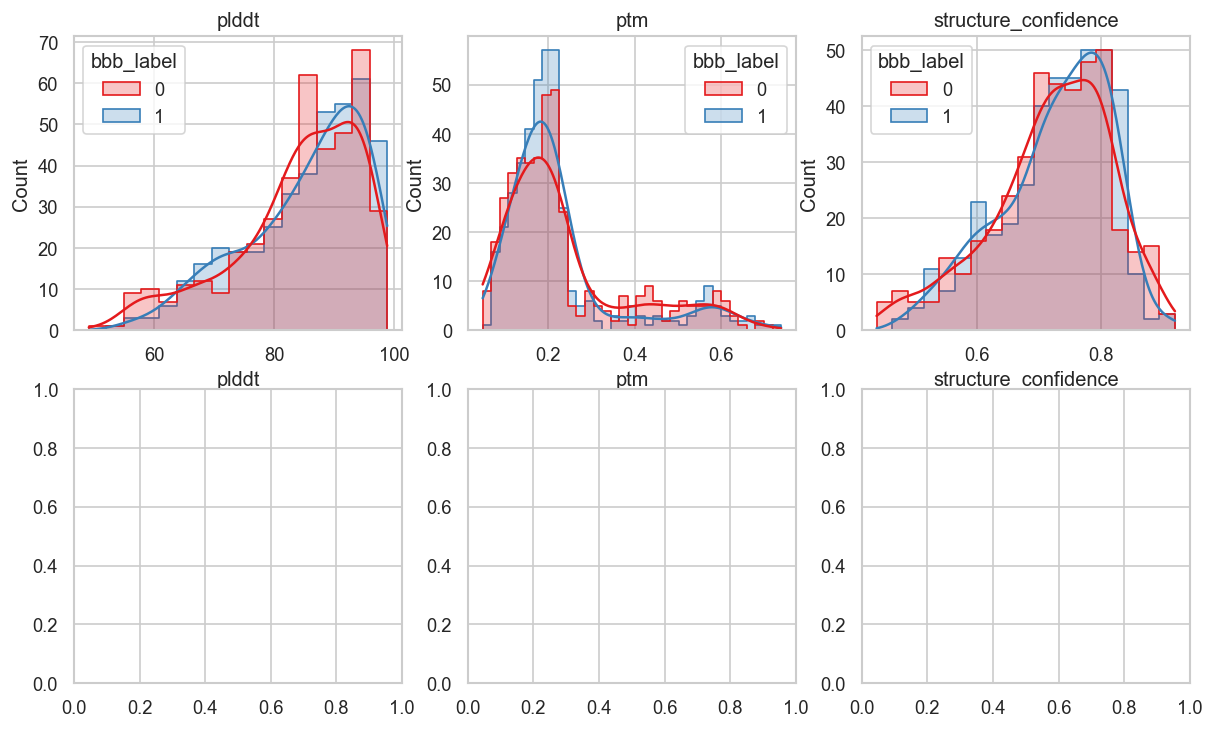

In [23]:
struct_out = EDA_DIR / "structures"
struct_out.mkdir(parents=True, exist_ok=True)

usable_struct = [c for c in STRUCT_COLS if c in struct_df.columns]
display(dataset_overview_table(struct_df, name="hf_with_structure"))

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, col in zip(axes.ravel(), usable_struct[:6], strict=False):
    sns.histplot(data=struct_df, x=col, hue="bbb_label", kde=True, element="step", ax=ax, palette="Set1")
    ax.set_title(col)
fig.suptitle("Boltz structure-quality metrics by BBB label", y=1.02)
fig.tight_layout()
save_fig(fig, struct_out / "struct_metric_histograms.png")

label_mean_heatmap(struct_df, usable_struct, "Median Boltz metrics by BBB label", struct_out / "struct_metric_heatmap.png")

mw_struct = mannwhitney_by_label(struct_df, usable_struct)
mw_struct.to_csv(struct_out / "struct_mannwhitney.csv", index=False)
display(mw_struct)

if {"plddt", "ptm"}.issubset(struct_df.columns):
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.scatterplot(data=struct_df, x="ptm", y="plddt", hue="bbb_label", alpha=0.5, ax=ax, palette="Set1")
    ax.set_title("pTM vs pLDDT (coloured by BBB label)")
    save_fig(fig, struct_out / "ptm_vs_plddt_scatter.png")

    fig = px.scatter(
        struct_df, x="ptm", y="plddt", color=struct_df["bbb_label"].map({0: "BBB−", 1: "BBB+"}),
        hover_data=["sequence", "length", "peptide_id"],
        title="Interactive: pTM vs pLDDT",
        opacity=0.65,
    )
    fig.write_html(struct_out / "ptm_vs_plddt_interactive.html")

pair_cols = [c for c in ["plddt", "ptm", "structure_confidence", "length", "gravy", "net_charge_ph7"] if c in struct_df.columns]
if len(pair_cols) >= 3:
    sample = struct_df.sample(min(400, len(struct_df)), random_state=RANDOM_SEED)
    g = sns.pairplot(sample, vars=pair_cols, hue="bbb_label", corner=True, plot_kws={"alpha": 0.45, "s": 12})
    g.fig.suptitle("Structure + tabular feature pairplot (sample)", y=1.02)
    save_fig(g.fig, struct_out / "struct_tabular_pairplot.png")

## 5. Per-residue pLDDT profiles & 3D peptide gallery

In [ ]:
import sys

_src = BASE_DIR / "src"
if _src.exists() and str(_src) not in sys.path:
    sys.path.insert(0, str(_src))
from bbb_dataset.struct_io import load_coords_npz


def resolve_coords_path(row: pd.Series) -> Path | None:
    rel = row.get("structure_coords_path")
    if pd.isna(rel):
        return None
    rel_path = Path(str(rel))
    if hf_struct_root is not None:
        candidate = hf_struct_root / rel_path
        if candidate.exists():
            return candidate
    candidate = BASE_DIR / "data" / rel_path
    return candidate if candidate.exists() else None


def load_peptide_coords(row: pd.Series) -> dict | None:
    path = resolve_coords_path(row)
    if path is None:
        return None
    payload = load_coords_npz(path)
    plddt = payload.get("plddt_per_residue")
    if isinstance(plddt, np.ndarray) and plddt.size == 0 and "plddt" in row:
        plddt = np.full(len(payload["sequence"]), float(row["plddt"]), dtype=np.float32)
    return {"coords": payload["coords"], "sequence": payload["sequence"], "plddt": plddt}


def plot_ca_trace_3d(coords: np.ndarray, plddt: np.ndarray | None, title: str) -> go.Figure:
    color = plddt if plddt is not None and len(plddt) == len(coords) else np.linspace(50, 90, len(coords))
    fig = go.Figure()
    fig.add_trace(go.Scatter3d(
        x=coords[:, 0], y=coords[:, 1], z=coords[:, 2],
        mode="lines+markers",
        marker=dict(size=4, color=color, colorscale="Viridis", showscale=True, colorbar=dict(title="pLDDT")),
        line=dict(width=4, color="gray"),
        name=title,
    ))
    fig.update_layout(title=title, margin=dict(l=0, r=0, t=40, b=0), scene=dict(aspectmode="data"))
    return fig


# Sample peptides for gallery: high/low pLDDT × BBB+/−
gallery_rows = []
for label in [0, 1]:
    subset = struct_df[struct_df["bbb_label"] == label].dropna(subset=["plddt"])
    if subset.empty:
        continue
    gallery_rows.append(subset.nlargest(1, "plddt"))
    gallery_rows.append(subset.nsmallest(1, "plddt"))
gallery = pd.concat(gallery_rows).drop_duplicates("peptide_id") if gallery_rows else struct_df.head(4)

plddt_profiles: list[np.ndarray] = []
profile_labels: list[str] = []
for _, row in gallery.iterrows():
    loaded = load_peptide_coords(row)
    if loaded is None:
        continue
    plddt = loaded.get("plddt")
    if plddt is None or len(plddt) == 0:
        continue
    plddt_profiles.append(np.asarray(plddt, dtype=float))
    profile_labels.append(f"{'BBB+' if row['bbb_label'] else 'BBB−'} | {row['sequence'][:12]}")
    title = f"{'BBB+' if row['bbb_label'] else 'BBB−'} {row['sequence']} (pLDDT={row.get('plddt', float('nan')):.1f})"
    fig3d = plot_ca_trace_3d(loaded["coords"], np.asarray(plddt, dtype=float), title)
    fig3d.write_html(struct_out / f"peptide_3d_{row['peptide_id']}.html")

if plddt_profiles:
    max_len = max(len(p) for p in plddt_profiles)
    mat = np.full((len(plddt_profiles), max_len), np.nan)
    for i, prof in enumerate(plddt_profiles):
        mat[i, : len(prof)] = prof
    fig, ax = plt.subplots(figsize=(10, max(3, len(plddt_profiles) * 0.45)))
    sns.heatmap(mat, cmap="viridis", ax=ax, yticklabels=profile_labels, cbar_kws={"label": "pLDDT"})
    ax.set_xlabel("Residue index")
    ax.set_title("Per-residue pLDDT profiles (gallery peptides)")
    save_fig(fig, struct_out / "plddt_profile_heatmap.png")

# py3Dmol inline view (first successful peptide)
try:
    import py3Dmol

    for _, row in gallery.iterrows():
        cif_rel = row.get("structure_cif_path")
        if pd.isna(cif_rel) or hf_struct_root is None:
            continue
        cif_path = hf_struct_root / str(cif_rel)
        if not cif_path.exists():
            continue
        cif_text = cif_path.read_text(encoding="utf-8", errors="ignore")
        view = py3Dmol.view(width=700, height=420)
        view.addModel(cif_text, "cif")
        view.setStyle({"cartoon": {"color": "spectrum"}})
        view.zoomTo()
        print(f"3D (py3Dmol): {row['sequence']} | label={row['bbb_label']}")
        view.show()
        break
except ImportError:
    print("Install py3dmol for inline CIF viewer: uv sync --package bbb-dataset --extra notebook")

3D (py3Dmol): KIAKLKAKIQKLKQKIAKLK | label=0


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 6. GSK3β target — design, guidance & hotspot map

Therapeutic context: cyclic disulfide-stapled peptide vs GSK3β kinase domain (1Q4L chain A) for **substrate-selective modulation** (not ATP-competitive inhibition). Design hotspots target the substrate-recognition groove; ATP cleft residues are repulsion targets in guidance and gate G2.

**Sources (BoltzGen campaign)**
| File | Role |
|------|------|
| `notebooks/gsk3b.cif` | Kinase structure for visualization (copy of target CIF) |
| `targets/gsk3b/gsk3b_peptide_design.yaml` | Peptide scaffold, binding types, proximity shell, disulfide |
| `targets/gsk3b/guidance.json` | Hotspot regions + guidance hyperparameters |
| `targets/gsk3b/guidance_feats.json` | Flat guidance keys passed to BoltzGen `design` stage |

Primary substrate-groove contacts: **R96, D180, K205** (`hotspots_primary` in `guidance.json`). ATP cleft residues (133–135, 200–206, etc.) appear only in `atp_cleft` for repulsion scoring.

In [24]:
from IPython.display import display

target_out = EDA_DIR / "target"
target_out.mkdir(parents=True, exist_ok=True)

THREE_TO_ONE = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D", "CYS": "C", "GLN": "Q", "GLU": "E",
    "GLY": "G", "HIS": "H", "ILE": "I", "LEU": "L", "LYS": "K", "MET": "M", "PHE": "F",
    "PRO": "P", "SER": "S", "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V",
}


def extract_chain_ca(cif_path: Path, chain_id: str = "A") -> pd.DataFrame:
    from Bio.PDB.MMCIFParser import MMCIFParser

    structure = MMCIFParser(QUIET=True).get_structure("gsk3b", str(cif_path))
    rows = []
    for model in structure:
        for chain in model:
            if chain.id != chain_id:
                continue
            for residue in chain:
                if residue.id[0] != " ":
                    continue
                resseq = int(residue.id[1])
                resname = residue.get_resname().upper()
                if "CA" not in residue:
                    continue
                ca = residue["CA"].coord
                aa = THREE_TO_ONE.get(resname, "X")
                rows.append({"resseq": resseq, "aa": aa, "x": ca[0], "y": ca[1], "z": ca[2]})
        break
    return pd.DataFrame(rows)


def _parse_binding_list(raw) -> list[int]:
    if isinstance(raw, list):
        return [int(x) for x in raw]
    if isinstance(raw, str):
        return [int(x.strip()) for x in raw.split(",") if x.strip()]
    return []


missing = [p for p in (GSK3B_CIF, GSK3B_DESIGN_YAML, GSK3B_GUIDANCE_JSON, GSK3B_GUIDANCE_FEATS) if not p.exists()]
if missing:
    print("Missing GSK3β campaign files — skip target section:")
    for p in missing:
        print(f"  - {p}")
else:
    design_cfg = yaml.safe_load(GSK3B_DESIGN_YAML.read_text(encoding="utf-8"))
    guidance_cfg = json.loads(GSK3B_GUIDANCE_JSON.read_text(encoding="utf-8"))
    guidance_feats = json.loads(GSK3B_GUIDANCE_FEATS.read_text(encoding="utf-8"))

    peptide_entity = next(e for e in design_cfg["entities"] if "protein" in e)
    target_entity = next(e for e in design_cfg["entities"] if "file" in e)
    target_file = target_entity["file"]
    binding_types = _parse_binding_list(
        target_file["binding_types"][0]["chain"]["binding"]
    )
    proximity = target_file.get("include_proximity", [{}])[0].get("chain", {})

    design_summary = pd.DataFrame(
        [
            {"field": "peptide_sequence", "value": peptide_entity["protein"]["sequence"]},
            {"field": "peptide_length", "value": len(peptide_entity["protein"]["sequence"])},
            {"field": "secondary_structure", "value": str(peptide_entity["protein"].get("secondary_structure", {}))},
            {"field": "disulfide_bond", "value": str(design_cfg.get("constraints", []))},
            {"field": "target_cif", "value": target_file["path"]},
            {"field": "target_chain", "value": target_file["include"][0]["chain"]["id"]},
            {"field": "target_res_index", "value": str(target_file["include"][0]["chain"]["res_index"])},
            {"field": "binding_types_count", "value": len(binding_types)},
            {"field": "proximity_radius_A", "value": proximity.get("radius")},
        ]
    )
    print("### Peptide design (`gsk3b_peptide_design.yaml`)")
    display(design_summary)

    binding_df = pd.DataFrame({"label_seq_id": binding_types}).sort_values("label_seq_id")
    binding_df["role"] = binding_df["label_seq_id"].map(
        lambda r: "binding_type"
        if r in binding_types
        else "other"
    )
    print("Binding-type residues (design yaml):")
    display(binding_df)

    region_rows = []
    for name, residues in guidance_cfg.items():
        if not name.startswith("hotspots") and name != "atp_cleft":
            continue
        for res in residues:
            region_rows.append({"label_seq_id": int(res), "region": name})
    regions_df = pd.DataFrame(region_rows).sort_values(["region", "label_seq_id"])
    print("Hotspot regions (`guidance.json`):")
    display(regions_df)

    guidance_rows = []
    for section, payload in [("guidance.json", guidance_cfg.get("guidance", {})), ("guidance_feats.json", guidance_feats)]:
        if section == "guidance_feats.json":
            for key, val in payload.items():
                guidance_rows.append({"source": section, "key": key, "value": val})
        else:
            flat = {
                **{k: v for k, v in payload.items() if not isinstance(v, dict)},
                **{f"bbb_{k}": v for k, v in payload.get("bbb", {}).items()},
            }
            for key, val in flat.items():
                guidance_rows.append({"source": section, "key": key, "value": val})
    guidance_table = pd.DataFrame(guidance_rows)
    print("Guidance hyperparameters:")
    display(guidance_table.pivot(index="key", columns="source", values="value"))

    primary = set(guidance_cfg.get("hotspots_primary", []))
    secondary = set(guidance_cfg.get("hotspots_secondary", []))
    atp_cleft = set(guidance_cfg.get("atp_cleft", []))
    binding_set = set(binding_types)

    chain_id = target_file["include"][0]["chain"]["id"]
    ca_df = extract_chain_ca(GSK3B_CIF, chain_id=chain_id)

    def region_label(resseq: int) -> str:
        if resseq in primary:
            return "primary_hotspot"
        if resseq in secondary:
            return "secondary_hotspot"
        if resseq in atp_cleft:
            return "atp_cleft"
        if resseq in binding_set:
            return "design_binding"
        return "other"

    ca_df["region"] = ca_df["resseq"].map(region_label)
    ca_df["label"] = ca_df.apply(lambda r: f"{r['aa']}{r['resseq']}", axis=1)
    ca_df.to_csv(target_out / "gsk3b_ca_hotspots.csv", index=False)

    palette = {
        "primary_hotspot": "#d62728",
        "secondary_hotspot": "#ff7f0e",
        "atp_cleft": "#1f77b4",
        "design_binding": "#9467bd",
        "other": "#bdbdbd",
    }
    fig = px.scatter_3d(
        ca_df,
        x="x",
        y="y",
        z="z",
        color="region",
        color_discrete_map=palette,
        hover_name="label",
        title="GSK3β (chain A) — guidance.json regions + design binding types",
        opacity=0.9,
    )
    fig.update_traces(marker=dict(size=4))
    fig.update_layout(scene=dict(aspectmode="data"), legend_title_text="Region")
    fig.write_html(target_out / "gsk3b_hotspots_3d.html")
    fig.show()

    hotspot_table = ca_df[ca_df["region"] != "other"].sort_values("resseq")
    print("Annotated CA atoms:")
    display(hotspot_table[["label", "region", "x", "y", "z"]])

    fig, ax = plt.subplots(figsize=(14, 3))
    order = ca_df.sort_values("resseq")
    ax.scatter(order["resseq"], np.zeros(len(order)), c=order["region"].map(palette), s=55)
    for resseq in sorted(primary):
        row = ca_df[ca_df["resseq"] == resseq]
        if not row.empty:
            ax.annotate(
                row.iloc[0]["label"],
                (resseq, 0),
                textcoords="offset points",
                xytext=(0, 10),
                ha="center",
                fontsize=9,
            )
    ax.set_yticks([])
    ax.set_xlabel("label_seq_id (chain A)")
    ax.set_title("GSK3β sequence map — primary hotspots R96, D180, K205")
    save_fig(fig, target_out / "gsk3b_hotspot_sequence_map.png")

    try:
        import py3Dmol

        cif_text = GSK3B_CIF.read_text(encoding="utf-8", errors="ignore")
        view = py3Dmol.view(width=760, height=480)
        view.addModel(cif_text, "cif")
        view.setStyle({"cartoon": {"color": "lightgray"}})
        for resseq in sorted(primary):
            view.addStyle({"resi": resseq, "chain": chain_id}, {"stick": {"colorscheme": "redCarbon"}})
        for resseq in sorted(binding_set - primary)[:12]:
            view.addStyle({"resi": resseq, "chain": chain_id}, {"stick": {"color": "purple"}})
        for resseq in sorted(atp_cleft - primary - binding_set)[:8]:
            view.addStyle({"resi": resseq, "chain": chain_id}, {"stick": {"color": "blue"}})
        view.zoomTo()
        view.show()
    except ImportError:
        pass

### Peptide design (`gsk3b_peptide_design.yaml`)


,field,value
0,peptide_sequence,2C9C2
1,peptide_length,5
2,secondary_structure,"{'sheet': '1,4..10'}"
3,disulfide_bond,"[{'bond': {'atom1': ['P', 3, 'SG'], 'atom2': [..."
4,target_cif,gsk3b.cif
5,target_chain,A
6,target_res_index,46..220
7,binding_types_count,16
8,proximity_radius_A,22


Binding-type residues (design yaml):


,label_seq_id,role
0,67,binding_type
1,85,binding_type
2,89,binding_type
3,95,binding_type
4,96,binding_type
5,133,binding_type
6,134,binding_type
7,135,binding_type
8,180,binding_type
9,200,binding_type


Hotspot regions (`guidance.json`):


...

Guidance hyperparameters:


source,guidance.json,guidance_feats.json
key,,
alpha,8.0,NaN
atp_weight,0.7,NaN
bbb_ckpt,../../bbb_models/artifacts/models/exp09_struct...,NaN
bbb_hidden,64,NaN
bbb_layers,3,NaN
bbb_membrane_weight,0.7,NaN
bbb_sigma_gate,4.0,NaN
bbb_weight,0.3,NaN
cutoff_angstrom,5.0,NaN


Annotated CA atoms:


,label,region,x,y,z
15,R50,atp_cleft,43.453999,31.298000,44.869999
32,F67,secondary_hotspot,35.525002,13.454000,24.916000
50,K85,atp_cleft,41.553001,14.424000,31.862000
54,Q89,secondary_hotspot,37.953999,23.378000,24.673000
60,N95,secondary_hotspot,32.692001,23.548000,29.690001
61,R96,primary_hotspot,29.580000,21.882999,31.162001
95,D133,atp_cleft,41.558998,11.824000,42.153000
96,Y134,atp_cleft,43.320000,8.748000,40.785999
97,V135,atp_cleft,41.814999,5.334000,41.529999
142,R180,primary_hotspot,23.452000,9.752000,32.123001


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 7. UMAP — physicochemical embedding

In [25]:
embed_out = EDA_DIR / "embedding"
embed_out.mkdir(parents=True, exist_ok=True)

try:
    import umap

    feat_cols = [c for c in FEATURE_COLS + AA_PCT_COLS if c in hf_df.columns]
    matrix = hf_df[feat_cols].astype(float).fillna(hf_df[feat_cols].median())
    reducer = umap.UMAP(n_components=2, random_state=RANDOM_SEED, n_neighbors=20, min_dist=0.15)
    embedding = reducer.fit_transform(matrix)
    emb_df = hf_df[["peptide_id", "sequence", "bbb_label", "length"]].copy()
    emb_df["umap1"] = embedding[:, 0]
    emb_df["umap2"] = embedding[:, 1]
    if "plddt" in hf_df.columns:
        emb_df["plddt"] = hf_df["plddt"]

    fig = px.scatter(
        emb_df, x="umap1", y="umap2",
        color=emb_df["bbb_label"].map({0: "BBB−", 1: "BBB+"}),
        symbol=emb_df.get("is_augmented", pd.Series(0, index=emb_df.index)).map({0: "gold", 1: "augmented"}),
        hover_data=["sequence", "length", "peptide_id"],
        title="UMAP of physicochemical features (HF dataset)",
        opacity=0.75,
    )
    fig.write_html(embed_out / "umap_bbb_label.html")
    fig.show()

    if "plddt" in emb_df.columns:
        fig2 = px.scatter(emb_df, x="umap1", y="umap2", color="plddt", color_continuous_scale="Viridis",
                          hover_data=["sequence", "bbb_label"], title="UMAP coloured by Boltz pLDDT")
        fig2.write_html(embed_out / "umap_plddt.html")

    fig3, ax = plt.subplots(figsize=(7, 6))
    sns.scatterplot(data=emb_df, x="umap1", y="umap2", hue="bbb_label", palette="Set1", alpha=0.6, ax=ax)
    ax.set_title("UMAP (static)")
    save_fig(fig3, embed_out / "umap_static.png")
except ImportError:
    print("umap-learn not installed — skip embedding section.")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

